<a href="https://colab.research.google.com/github/Rogerio-mack/AD_solucao/blob/main/Aula_04_HousePrice_Co2_Eletricity_graficos_e_correlacao_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [14]:
df = pd.read_excel('http://meusite.mackenzie.br/rogerio/data_load/regressao_preco_imoveis.xlsx')
display(df.head())

df.describe(include='all')


,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
0,vila-nova-conceicao,32,1,1,1,1,490000
1,vila-nova-conceicao,157,2,2,2,2,3180000
2,vila-nova-conceicao,205,2,3,3,3,1900000
3,vila-nova-conceicao,193,3,3,3,3,3565000
4,vila-nova-conceicao,116,1,3,2,2,1605000


,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
count,3741,3741.000000,3741.000000,3741.000000,3741.000000,3741.000000,3.741000e+03
unique,5,NaN,NaN,NaN,NaN,NaN,NaN
top,vila-mariana,NaN,NaN,NaN,NaN,NaN,NaN
freq,1714,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,140.343758,1.700882,2.946271,3.095429,2.225341,1.553746e+06
std,NaN,60.051791,0.994945,0.759292,1.372859,1.000940,1.073607e+06
min,NaN,20.000000,1.000000,1.000000,1.000000,1.000000,2.800000e+05
25%,NaN,94.000000,1.000000,3.000000,2.000000,1.000000,8.500000e+05
50%,NaN,130.000000,1.000000,3.000000,3.000000,2.000000,1.200000e+06
75%,NaN,180.000000,2.000000,3.000000,4.000000,3.000000,1.880000e+06


# Distribuição dos Dados

- Histograma x Gráfico de Densidade de Probabilidade
- Script Layer

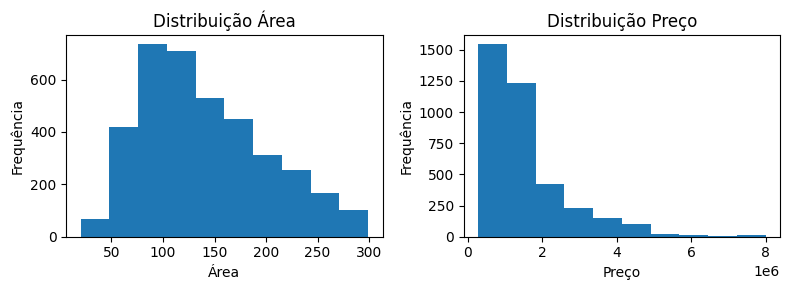

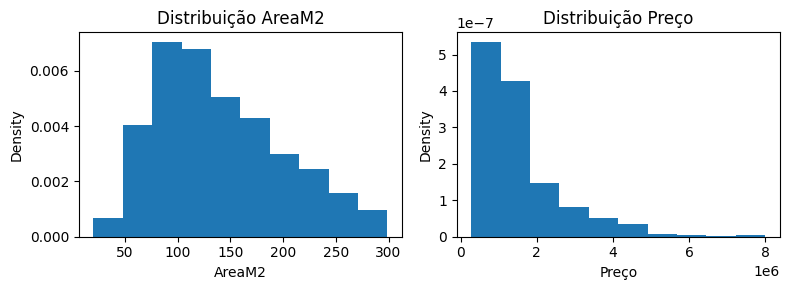

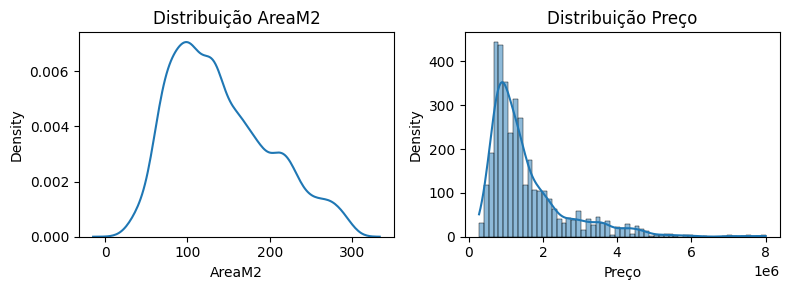

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
plt.hist(df.areaM2)
plt.title('Distribuição Área'); plt.xlabel('Área'); plt.ylabel('Frequência')

plt.subplot(1,2,2)
plt.hist(df.preco)
plt.title('Distribuição Preço'); plt.xlabel('Preço'); plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
plt.hist(df.areaM2,density=True)
plt.title('Distribuição AreaM2'); plt.xlabel('AreaM2'); plt.ylabel('Density')

plt.subplot(1,2,2)
plt.hist(df.preco,density=True)
plt.title('Distribuição Preço'); plt.xlabel('Preço'); plt.ylabel('Density')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
sns.kdeplot(df.areaM2)
plt.title('Distribuição AreaM2'); plt.xlabel('AreaM2'); plt.ylabel('Density')

plt.subplot(1,2,2)
sns.histplot(df.preco,kde=True)
plt.title('Distribuição Preço'); plt.xlabel('Preço'); plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Gráficos de Linha e Dispersão

- Correlação

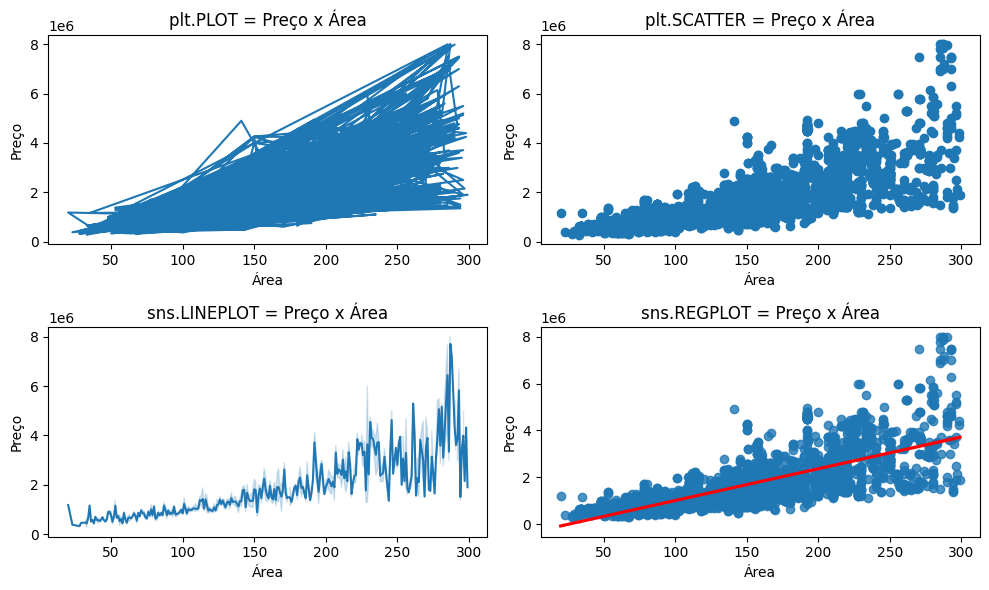

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

plt.figure(figsize=(10, 6))

plt.subplot(2,2,1)
plt.plot(df.areaM2, df.preco)
plt.title('plt.PLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

plt.subplot(2,2,2)
plt.scatter(df.areaM2, df.preco)
plt.title('plt.SCATTER = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

plt.subplot(2,2,3)
sns.lineplot(x=df.areaM2, y=df.preco)
plt.title('sns.LINEPLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

plt.subplot(2,2,4)
sns.regplot(x="areaM2", y="preco", data=df, line_kws=dict(color="r"))
plt.title('sns.REGPLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

plt.tight_layout()
plt.show()

# Explorando relações

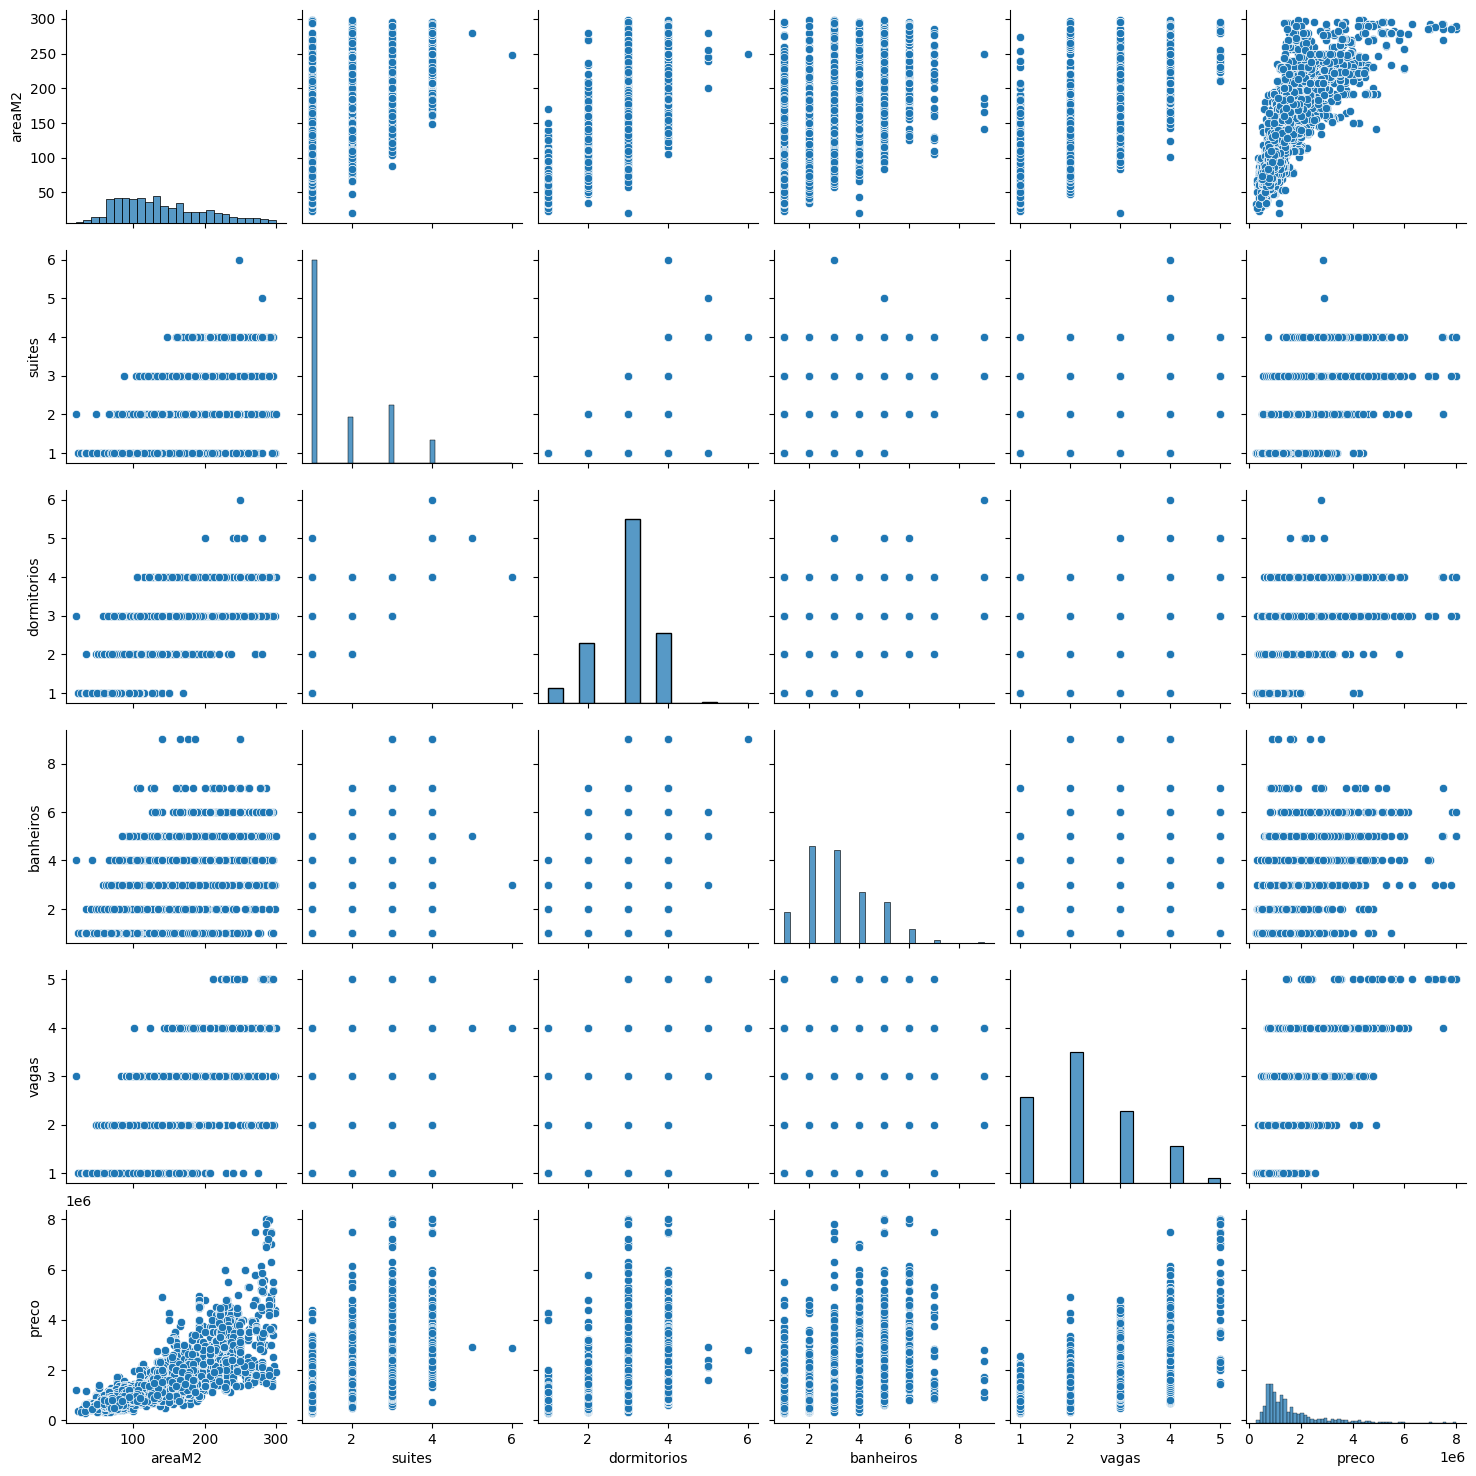

In [39]:
sns.pairplot(df)

plt.show()

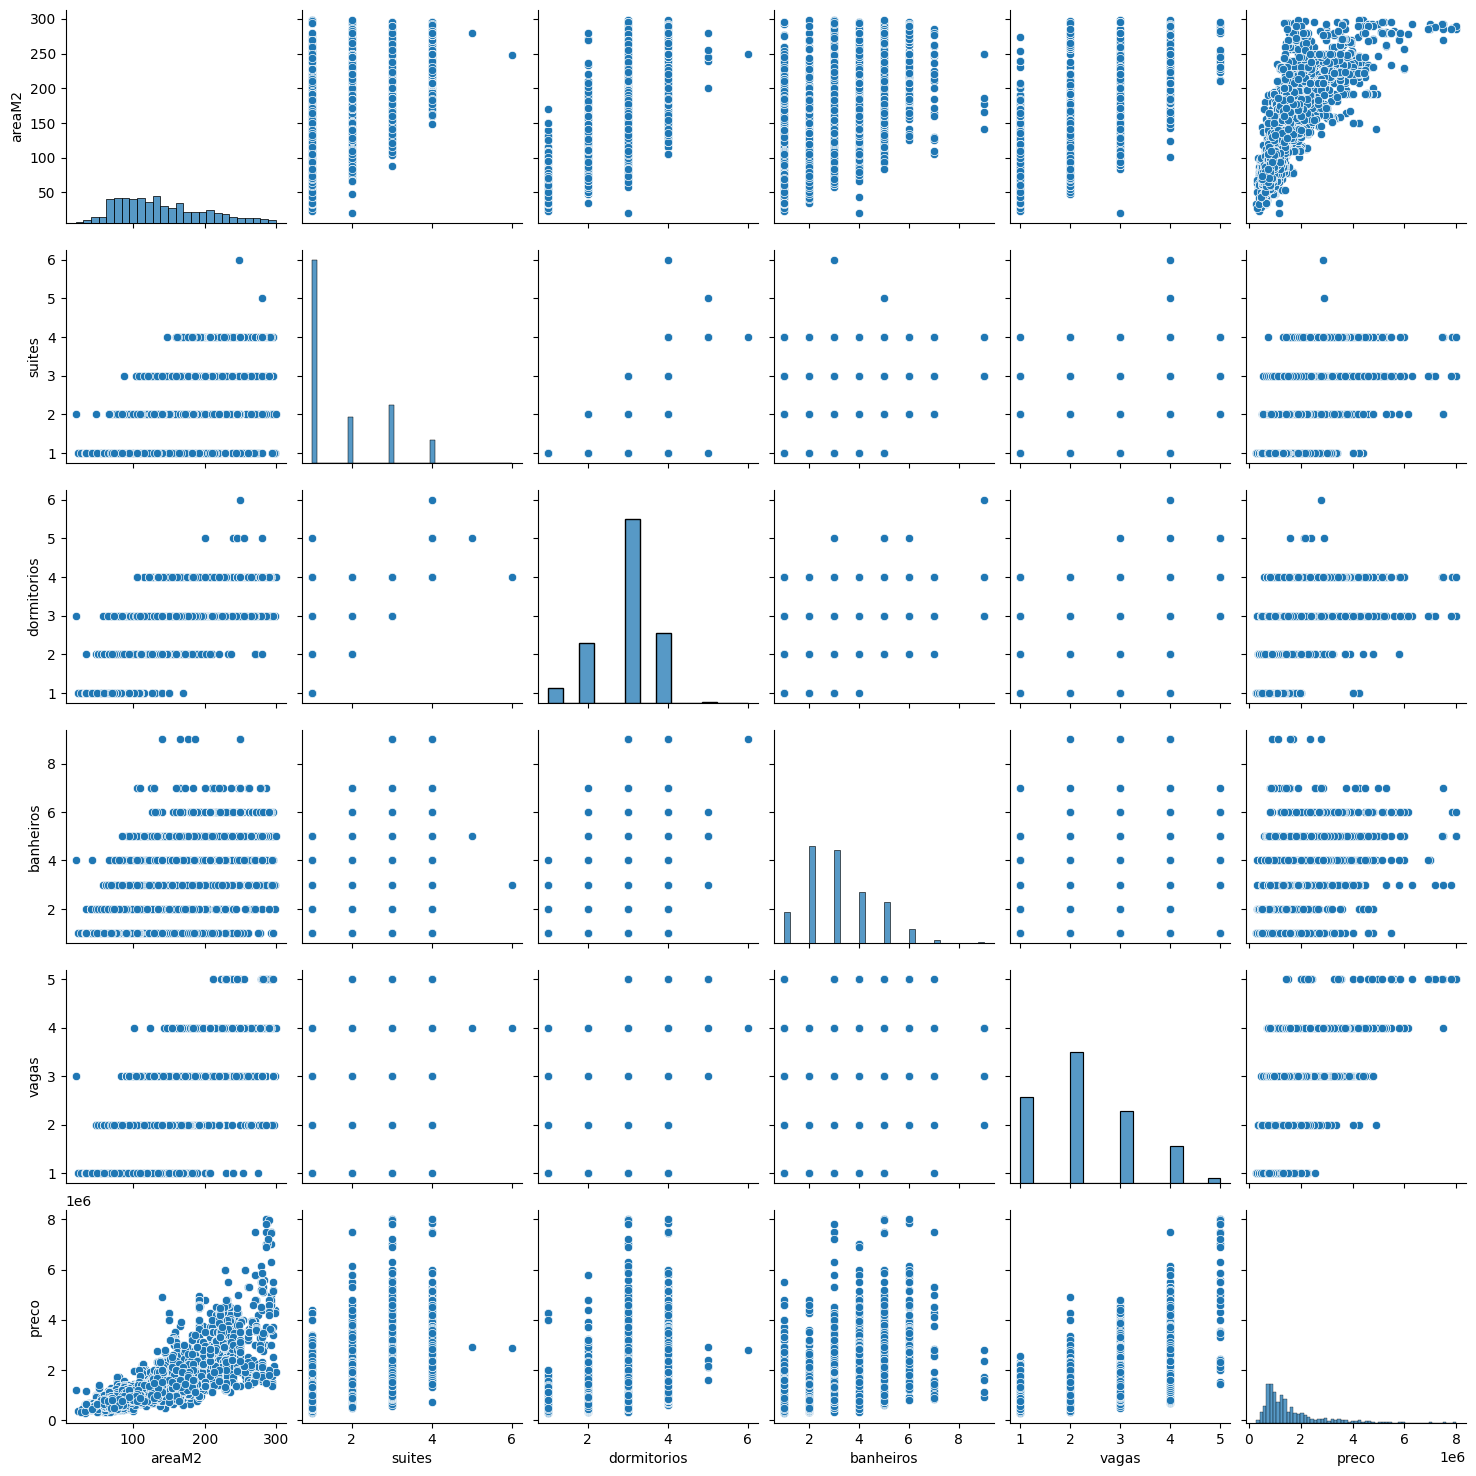

In [40]:
sns.pairplot(df.select_dtypes(include='number'))

plt.show()

# Artist Layer

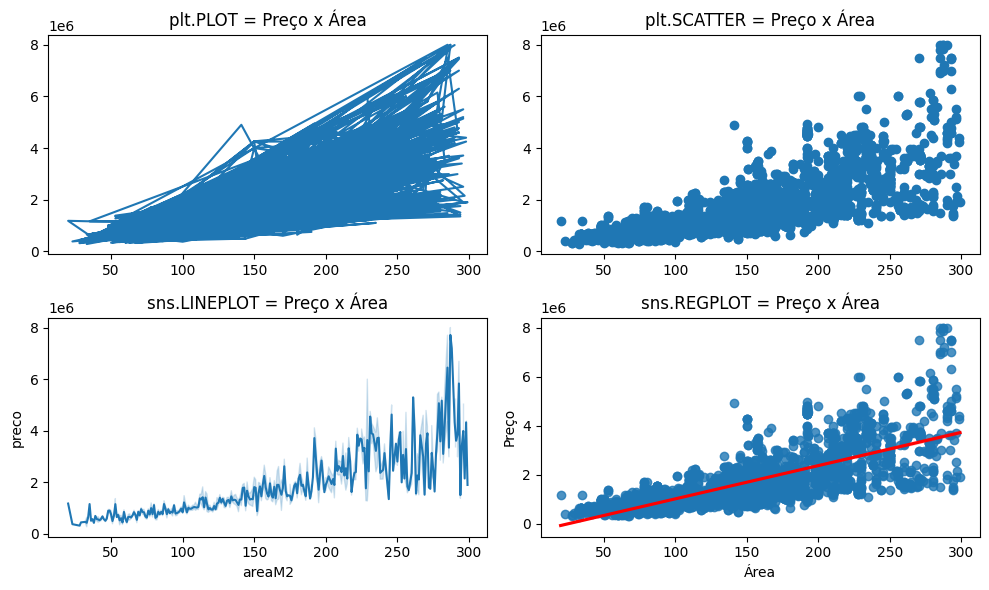

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

fig, ax = plt.subplots(2,2,figsize=(10, 6))
ax = ax.flatten()

ax[0].plot(df.areaM2, df.preco)
ax[0].set_title('plt.PLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

ax[1].scatter(df.areaM2, df.preco)
ax[1].set_title('plt.SCATTER = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

sns.lineplot(x=df.areaM2, y=df.preco, ax=ax[2])
ax[2].set_title('sns.LINEPLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

sns.regplot(x="areaM2", y="preco", data=df, line_kws=dict(color="r"), ax=ax[3])
ax[3].set_title('sns.REGPLOT = Preço x Área'); plt.xlabel('Área'); plt.ylabel('Preço')

plt.tight_layout()
plt.show()

# Correlação

$$ r = \frac{Cov(X,Y)}{\sigma_x \sigma_y} =\frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \cdot \sum (Y_i - \bar{Y})^2}}
$$

- $r = 1$: Correlação linear positiva perfeita
- $r = -1$: Correlação linear negativa perfeita
- $r = 0$: Ausência de correlação **linear**

In [44]:
df.select_dtypes(include='number').corr(method='pearson')

,areaM2,suites,dormitorios,banheiros,vagas,preco
areaM2,1.000000,0.656425,0.651620,0.586696,0.702664,0.759823
suites,0.656425,1.000000,0.480597,0.670404,0.726295,0.667402
dormitorios,0.651620,0.480597,1.000000,0.535626,0.479976,0.384469
banheiros,0.586696,0.670404,0.535626,1.000000,0.584621,0.502994
vagas,0.702664,0.726295,0.479976,0.584621,1.000000,0.718905
preco,0.759823,0.667402,0.384469,0.502994,0.718905,1.000000


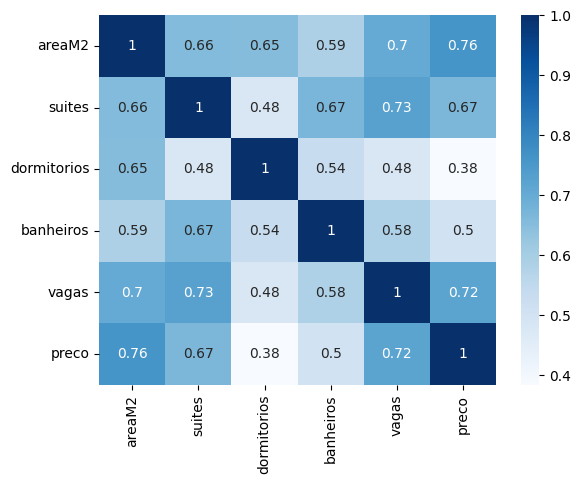

In [46]:
sns.heatmap(df.select_dtypes(include='number').corr(method='pearson'), annot=True, cmap='Blues')

plt.show()

## Cuidado

- $r \approx 0$, não existe correlação de $x$ e $y$?
- $r \approx 1$,  $x$ e $y$ são causa-efeito?

In [51]:
import numpy as np
np.corrcoef(df.areaM2, df.preco)

array([[1.        , 0.75982348],
       [0.75982348, 1.        ]])

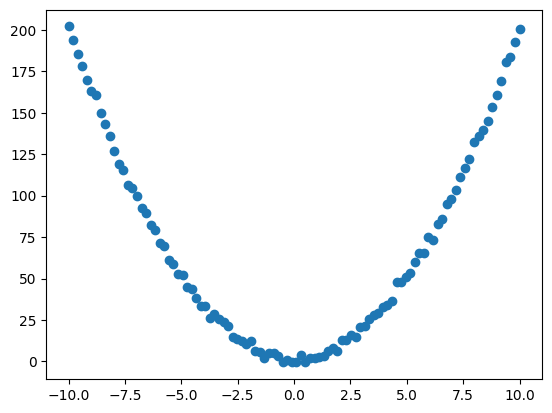

array([[ 1.        , -0.00227814],
       [-0.00227814,  1.        ]])

In [54]:
import numpy as np
x = np.linspace(-10, 10, 100)
y = 2 * x**2+ 1 + np.random.normal(0, 2, 100)
plt.scatter(x, y)
plt.show()
np.corrcoef(x,y)

Ver: https://www.tylervigen.com/spurious-correlations


# Exercício

Acesse os datasets abaixo. Entenda as operações efetuadas para o "merge" dos dados. Responda em seguida as perguntas.

1. Mostre graficamente que, no ano 2000, as maiores emissões foram feitas por poucos países. Ajuste, se necessário, o intervalo de valores para um exibição dos dados. Que tipo de distribuição você encontra?

2. Relacione os 5 **países** maiores emissores e os 5 **países** maiores geradores de energia elétrica no ano 2000.

3. Mostre graficamente a dispersão dos dados de emissões e geração da China e Brasil.

4. Qual dos países tiveram ao longo dos anos emissões e geração mais correlacionados. Quais os valores dessas correlações? Podemos afirmar que o Brasil tem uma correlação maior dos valores e que, portanto, gera mais emissões por Kwh de energia produzido?

In [55]:
country_entities = pd.read_csv('https://github.com/open-numbers/ddf--gapminder--co2_emission/raw/master/ddf--entities--country.csv')
co2_emissions = pd.read_csv('https://github.com/open-numbers/ddf--gapminder--co2_emission/raw/master/ddf--datapoints--yearly_co2_emissions_1000_tonnes--by--country--year.csv')
co2_by_country = country_entities.merge(co2_emissions, how='inner', left_on='country', right_on='country')

co2_by_country.name = co2_by_country.name.str.lower()
co2_by_country.head()

,country,name,year,yearly_co2_emissions_1000_tonnes
0,abw,aruba,1959,719.95990
1,abw,aruba,1960,619.06729
2,abw,aruba,1961,646.08113
3,abw,aruba,1962,709.52273
4,abw,aruba,1963,679.64379


In [56]:
eletricity_by_country = pd.read_csv('https://github.com/open-numbers/ddf--bp--energy/raw/master/ddf--datapoints--electricity_generation_twh--by--geo--year.csv')
eletricity_by_country.head()

,geo,year,electricity_generation_twh
0,canada,1985,459.01640
1,mexico,1985,96.20753
2,united_states,1985,2657.15007
3,total_north_america,1985,3212.37400
4,argentina,1985,45.30373


## Solução

### Q1

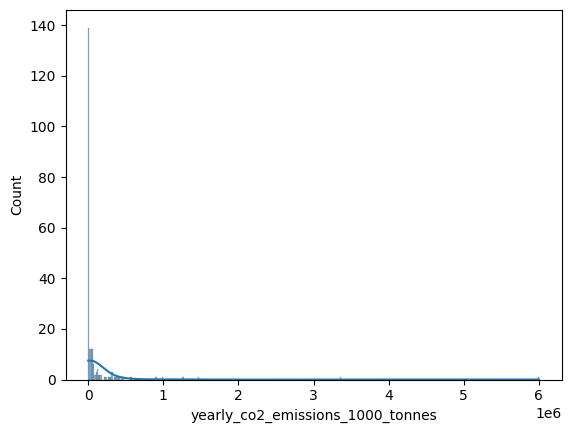

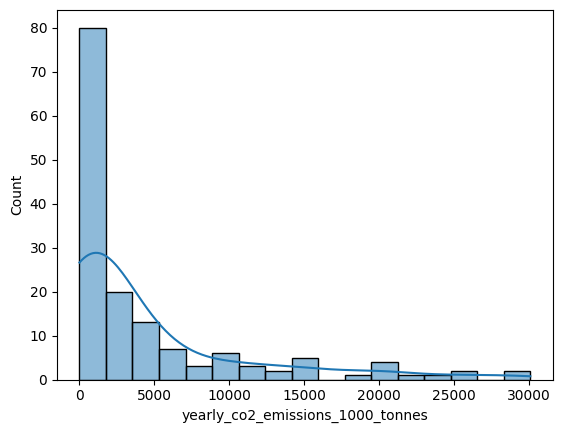

In [76]:
sns.histplot(co2_by_country[(co2_by_country.year == 2000)].yearly_co2_emissions_1000_tonnes,fill=True,kde=True)
plt.show()

sns.histplot(co2_by_country[(co2_by_country.year == 2000) &
            (co2_by_country.yearly_co2_emissions_1000_tonnes < co2_by_country.yearly_co2_emissions_1000_tonnes.quantile(.75))].yearly_co2_emissions_1000_tonnes,fill=True,kde=True)
plt.show()

### Q2

In [80]:
# co2_by_country[(co2_by_country.year == 2000)].yearly_co2_emissions_1000_tonnes.nlargest(5)
co2_by_country[(co2_by_country.year == 2000)].nlargest(5,"yearly_co2_emissions_1000_tonnes")

,country,name,year,yearly_co2_emissions_1000_tonnes
19226,usa,usa,2000,6.002982e+06
3761,chn,china,2000,3.352037e+06
15740,rus,russia,2000,1.472257e+06
9953,jpn,japan,2000,1.265880e+06
9008,ind,india,2000,9.792203e+05


In [82]:
eletricity_by_country[(eletricity_by_country.year == 2000)].nlargest(5,"electricity_generation_twh")

,geo,year,electricity_generation_twh
1583,total_world,2000,15564.69644
1488,total_north_america,2000,4859.69727
1582,total_asia_pacific,2000,4286.58253
1487,united_states,2000,4052.25311
1535,total_europe,2000,3619.41249


In [86]:
# eletricity_by_country[(eletricity_by_country.year == 2000)].nlargest(5,"electricity_generation_twh")
eletricity_by_country[(eletricity_by_country.year == 2000) &
                      ~eletricity_by_country['geo'].str.contains('total')].nlargest(5,"electricity_generation_twh")


,geo,year,electricity_generation_twh
1487,united_states,2000,4052.25311
1566,china,2000,1355.60000
1570,japan,2000,1099.67100
1539,russian_federation,2000,877.76400
1485,canada,2000,603.81611


### Q3

In [87]:
co2_eletricity = co2_by_country.merge(eletricity_by_country, how='inner', left_on=['name','year'], right_on=['geo','year'])
co2_eletricity = co2_eletricity[ (co2_eletricity.name == 'china') | (co2_eletricity.name == 'brazil') ]
co2_eletricity.head()

,country,name,year,yearly_co2_emissions_1000_tonnes,geo,electricity_generation_twh
280,bra,brazil,1985,180084.10797,brazil,193.68223
281,bra,brazil,1986,197387.70145,brazil,202.12890
282,bra,brazil,1987,205957.23674,brazil,203.33147
283,bra,brazil,1988,207732.91541,brazil,214.95285
284,bra,brazil,1989,212287.31749,brazil,221.73902


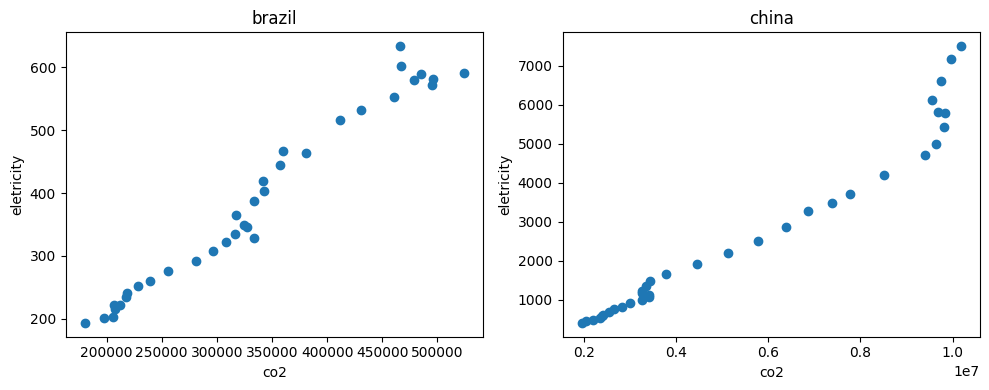

In [92]:
plt.figure(figsize=(10, 4))

for i, country in enumerate(co2_eletricity.name.unique()):
  plt.subplot(1,2,i+1)
  plt.scatter(co2_eletricity[ co2_eletricity.name == country ].yearly_co2_emissions_1000_tonnes,
              co2_eletricity[ co2_eletricity.name == country ].electricity_generation_twh)
  plt.title(country)
  plt.xlabel('co2')
  plt.ylabel('eletricity')

plt.tight_layout()
plt.show()

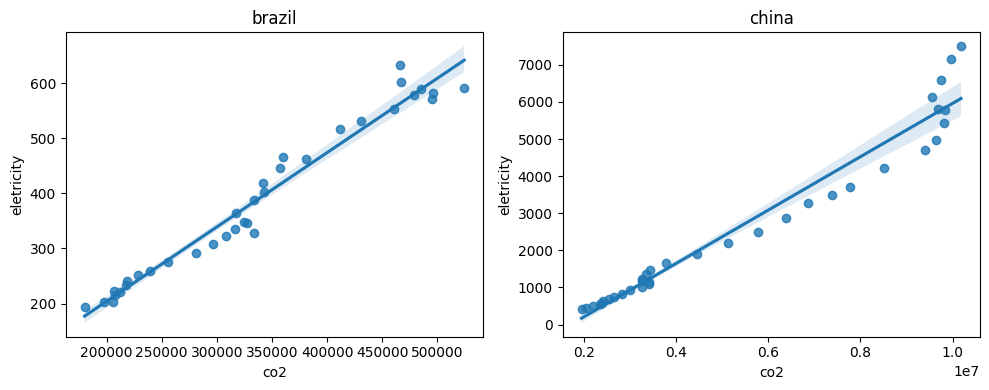

In [94]:
plt.figure(figsize=(10, 4))

for i, country in enumerate(co2_eletricity.name.unique()):
  plt.subplot(1,2,i+1)
  sns.regplot(x=co2_eletricity[ co2_eletricity.name == country ].yearly_co2_emissions_1000_tonnes,
             y=co2_eletricity[ co2_eletricity.name == country ].electricity_generation_twh)
  plt.title(country)
  plt.xlabel('co2')
  plt.ylabel('eletricity')

plt.tight_layout()
plt.show()

### Q4

In [97]:
co2_eletricity[ co2_eletricity.name == country ][['yearly_co2_emissions_1000_tonnes','electricity_generation_twh']].corr().loc['yearly_co2_emissions_1000_tonnes','electricity_generation_twh']

np.float64(0.9764703314608674)

In [98]:
for i, country in enumerate(co2_eletricity.name.unique()):
  c_pearson = co2_eletricity[ co2_eletricity.name == country ][['yearly_co2_emissions_1000_tonnes','electricity_generation_twh']].corr().loc['yearly_co2_emissions_1000_tonnes','electricity_generation_twh']
  print(f'Correlation {country}: {c_pearson}')



Correlation brazil: 0.9830043862531803
Correlation china: 0.9764703314608674
